In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans



In [3]:

df = pd.read_csv("geochem_raw.csv", encoding='latin1') 
print(df.shape)
df.head()


(1366, 103)


,LAB_ID,PREVIOUS_LAB_ID1,PREVIOUS_LAB_ID2,PREVIOUS_LAB_ID3,FIELD_ID,JOB_ID,PREVIOUS_JOB_ID1,PREVIOUS_JOB_ID2,PREVIOUS_JOB_ID3,SUBMITTER,...,Th_ppm_MS_ST,Tl_ppm_MS_ST,Tm_ppm_MS_ST,U_ppm_MS_ST,V_ppm_AES_ST,W_ppm_MS_ST,Y_ppm_MS_ST,Yb_ppm_MS_ST,Zn_ppm_AES_ST,Zr_ppm_AES_ST
0,C355417,NaN,NaN,NaN,RM0001,MRP11968,NaN,NaN,NaN,Rare Metals Task,...,0.2,-0.5,-0.05,0.30,51.0,-1.0,-0.5,-0.1,1290.0,3.8
1,C360759,NaN,NaN,NaN,RM0027,MRP12307,NaN,NaN,NaN,Rare Metals Task,...,9.7,0.5,-0.05,1.75,24.0,28.0,2.3,0.3,-5.0,133.0
2,C360762,NaN,NaN,NaN,RM0030,MRP12307,NaN,NaN,NaN,Rare Metals Task,...,2.6,-0.5,0.08,0.63,-5.0,22.0,5.9,0.6,161.0,16.2
3,C360763,NaN,NaN,NaN,RM0031,MRP12307,NaN,NaN,NaN,Rare Metals Task,...,0.2,-0.5,-0.05,34.80,493.0,11.0,1.9,0.2,29.0,19.1
4,C360769,NaN,NaN,NaN,RM0037,MRP12307,NaN,NaN,NaN,Rare Metals Task,...,2.6,-0.5,0.22,31.20,68.0,8.0,13.0,1.4,4480.0,150.0


In [4]:
for col in df.columns:
    print(col)

LAB_ID
PREVIOUS_LAB_ID1
PREVIOUS_LAB_ID2
PREVIOUS_LAB_ID3
FIELD_ID
JOB_ID
PREVIOUS_JOB_ID1
PREVIOUS_JOB_ID2
PREVIOUS_JOB_ID3
SUBMITTER
PROJECT_NAME
DATE_SUBMITTED
COLLECTION
COLLECTION_ID
CONTINENT
COUNTRY
STATE_PROVINCE
COUNTY
DISTRICT_NAME
DEPOSIT_NAME
MINE_NAME
DISTRICT_NAME_COLLECT
DEPOSIT_NAME_COLLECT
MINE_NAME_COLLECT
LOCATE_DESC
LATITUDE
LONGITUDE
DATUM
LATITUDE_COLLECT
LONGITUDE_COLLECT
DATUM_COLLECT
COORDINATES_QUAL
COORDINATES_SOURCE
PRIMARY_CLASS
SYSTEM_TYPE
DEPOSIT_TYPE
SAMPLE_DESC
Al_pct_AES_ST
Ca_pct_AES_ST
Fe_pct_AES_ST
K_pct_AES_ST
Mg_pct_AES_ST
Mn_pct_AES_ST
P_pct_AES_ST
S_pct_AES_ST
Si_pct_AES_ST
Ti_pct_AES_ST
F_pct_ISE_Fuse
Ag_ppm_MS_ST
As_ppm_MS_ST
Au_ppm
Au_AM
B_ppm_AES_ST
Ba_ppm_AES_ST
Be_ppm_AES_ST
Bi_ppm_MS_ST
Cd_ppm_MS_ST
Ce_ppm_MS_ST
Co_ppm_MS_ST
Cr_ppm_AES_ST
Cs_ppm_MS_ST
Cu_ppm_AES_ST
Dy_ppm_MS_ST
Er_ppm_MS_ST
Eu_ppm_MS_ST
Ga_ppm_MS_ST
Gd_ppm_MS_ST
Ge_ppm_MS_ST
Hf_ppm_MS_ST
Ho_ppm_MS_ST
In_ppm_MS_ST
La_ppm_MS_ST
Li_ppm_AES_ST
Lu_ppm_MS_ST
Mo_ppm_MS_ST
Nb_ppm

In [5]:
cols_to_keep = [
    'LAB_ID', 'LATITUDE', 'LONGITUDE',
    'Al_pct_AES_ST', 'Ca_pct_AES_ST', 'Fe_pct_AES_ST', 'K_pct_AES_ST',
    'Mg_pct_AES_ST', 'Mn_pct_AES_ST', 'P_pct_AES_ST', 'S_pct_AES_ST',
    'Si_pct_AES_ST', 'Ti_pct_AES_ST',
    'Au_ppm', 'Ag_ppm_MS_ST', 'As_ppm_MS_ST', 'Cu_ppm_AES_ST', 'Pb_ppm_MS_ST',
    'Zn_ppm_AES_ST', 'Ni_ppm_AES_ST', 'Cr_ppm_AES_ST', 'Co_ppm_MS_ST',
    'Mo_ppm_MS_ST', 'U_ppm_MS_ST', 'Th_ppm_MS_ST', 'V_ppm_AES_ST'
]

df_col = df[cols_to_keep].copy()
df_col.to_csv("geochem_clean.csv", index=False)

In [6]:
# Step 1: Exploratory Data Analysis (EDA)
print("\nDataset Info Before Cleaning:")
df_col.info()
print("\nMissing Values Before Cleaning:\n", df_col.isnull().sum())
print("\nDuplicate Rows Before Cleaning:", df_col.duplicated().sum())


Dataset Info Before Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1366 entries, 0 to 1365
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LAB_ID         1366 non-null   object 
 1   LATITUDE       1362 non-null   float64
 2   LONGITUDE      1362 non-null   float64
 3   Al_pct_AES_ST  1336 non-null   float64
 4   Ca_pct_AES_ST  1336 non-null   float64
 5   Fe_pct_AES_ST  1336 non-null   float64
 6   K_pct_AES_ST   1336 non-null   float64
 7   Mg_pct_AES_ST  1336 non-null   float64
 8   Mn_pct_AES_ST  1336 non-null   float64
 9   P_pct_AES_ST   1336 non-null   float64
 10  S_pct_AES_ST   596 non-null    float64
 11  Si_pct_AES_ST  596 non-null    float64
 12  Ti_pct_AES_ST  1336 non-null   float64
 13  Au_ppm         201 non-null    float64
 14  Ag_ppm_MS_ST   1335 non-null   float64
 15  As_ppm_MS_ST   1336 non-null   float64
 16  Cu_ppm_AES_ST  1336 non-null   float64
 17  Pb_ppm_MS_ST   1336 n

In [7]:
# Dropping Au_ppm, S_pct_AES_ST,Si_pct_AES_ST  since it contains more than 50% of null values

print("\nHandling Missing Values...")
df_col = df_col.drop(columns=['Au_ppm', 'Si_pct_AES_ST', 'S_pct_AES_ST'])
print(df_col.shape)   # to check how many columns remain
print(df_col.head())  # to preview first 5 rows



Handling Missing Values...
(1366, 23)
    LAB_ID  LATITUDE  LONGITUDE  Al_pct_AES_ST  Ca_pct_AES_ST  Fe_pct_AES_ST  \
0  C355417  38.94021 -119.05178           0.33            1.1          42.40   
1  C360759 -22.28710  -68.89910           6.65            0.4           0.25   
2  C360762 -21.03090  -68.74951           0.46           -0.1           6.98   
3  C360763 -24.70000   29.30000           0.70            0.3          27.80   
4  C360769  62.74842   29.00282           9.48            8.5           8.92   

   K_pct_AES_ST  Mg_pct_AES_ST  Mn_pct_AES_ST  P_pct_AES_ST  ...  \
0          -0.1           0.57           0.02         -0.01  ...   
1           6.1           0.10          -0.01          0.01  ...   
2           0.2           0.01          -0.01          0.05  ...   
3          -0.1           0.33          -0.01          0.01  ...   
4           0.4           7.39           0.04          0.06  ...   

   Cu_ppm_AES_ST  Pb_ppm_MS_ST  Zn_ppm_AES_ST  Ni_ppm_AES_ST  Cr_ppm_AE

In [8]:
print("\nMissing Values After Handling:\n", df_col.isnull().sum())



Missing Values After Handling:
 LAB_ID            0
LATITUDE          4
LONGITUDE         4
Al_pct_AES_ST    30
Ca_pct_AES_ST    30
Fe_pct_AES_ST    30
K_pct_AES_ST     30
Mg_pct_AES_ST    30
Mn_pct_AES_ST    30
P_pct_AES_ST     30
Ti_pct_AES_ST    30
Ag_ppm_MS_ST     31
As_ppm_MS_ST     30
Cu_ppm_AES_ST    30
Pb_ppm_MS_ST     30
Zn_ppm_AES_ST    30
Ni_ppm_AES_ST    30
Cr_ppm_AES_ST    30
Co_ppm_MS_ST     30
Mo_ppm_MS_ST     30
U_ppm_MS_ST      30
Th_ppm_MS_ST     30
V_ppm_AES_ST     32
dtype: int64


In [9]:
rename_map = {
    'LAB_ID': 'Sample_ID',
    'LATITUDE': 'Latitude',
    'LONGITUDE': 'Longitude',
    'Al_pct_AES_ST': 'Al_pct',
    'Ca_pct_AES_ST': 'Ca_pct',
    'Fe_pct_AES_ST': 'Fe_pct',
    'K_pct_AES_ST': 'K_pct',
    'Mg_pct_AES_ST': 'Mg_pct',
    'Mn_pct_AES_ST': 'Mn_pct',
    'P_pct_AES_ST': 'P_pct',
    'Ti_pct_AES_ST': 'Ti_pct',
    'Ag_ppm_MS_ST': 'Ag_ppm',
    'As_ppm_MS_ST': 'As_ppm',
    'Cu_ppm_AES_ST': 'Cu_ppm',
    'Pb_ppm_MS_ST': 'Pb_ppm',
    'Zn_ppm_AES_ST': 'Zn_ppm',
    'Ni_ppm_AES_ST': 'Ni_ppm',
    'Cr_ppm_AES_ST': 'Cr_ppm',
    'Co_ppm_MS_ST': 'Co_ppm',
    'Mo_ppm_MS_ST': 'Mo_ppm',
    'U_ppm_MS_ST': 'U_ppm',
    'Th_ppm_MS_ST': 'Th_ppm',
    'V_ppm_AES_ST': 'V_ppm'
}

df_col.rename(columns=rename_map, inplace=True)


In [10]:
print(df_col.shape)       # check rows and cols
print(df_col.columns)     # check new names
df_col.head()             # preview first rows


(1366, 23)
Index(['Sample_ID', 'Latitude', 'Longitude', 'Al_pct', 'Ca_pct', 'Fe_pct',
       'K_pct', 'Mg_pct', 'Mn_pct', 'P_pct', 'Ti_pct', 'Ag_ppm', 'As_ppm',
       'Cu_ppm', 'Pb_ppm', 'Zn_ppm', 'Ni_ppm', 'Cr_ppm', 'Co_ppm', 'Mo_ppm',
       'U_ppm', 'Th_ppm', 'V_ppm'],
      dtype='object')


,Sample_ID,Latitude,Longitude,Al_pct,Ca_pct,Fe_pct,K_pct,Mg_pct,Mn_pct,P_pct,...,Cu_ppm,Pb_ppm,Zn_ppm,Ni_ppm,Cr_ppm,Co_ppm,Mo_ppm,U_ppm,Th_ppm,V_ppm
0,C355417,38.94021,-119.05178,0.33,1.1,42.40,-0.1,0.57,0.02,-0.01,...,50000.11111,23.0,1290.0,144.0,-10.0,209.0,-2.0,0.30,0.2,51.0
1,C360759,-22.28710,-68.89910,6.65,0.4,0.25,6.1,0.10,-0.01,0.01,...,23300.00000,16.0,-5.0,6.0,-10.0,-0.5,60.0,1.75,9.7,24.0
2,C360762,-21.03090,-68.74951,0.46,-0.1,6.98,0.2,0.01,-0.01,0.05,...,50000.11111,188.0,161.0,-5.0,-10.0,1.3,3.0,0.63,2.6,-5.0
3,C360763,-24.70000,29.30000,0.70,0.3,27.80,-0.1,0.33,-0.01,0.01,...,50000.11111,39.0,29.0,48.0,30.0,44.8,2.0,34.80,0.2,493.0
4,C360769,62.74842,29.00282,9.48,8.5,8.92,0.4,7.39,0.04,0.06,...,18600.00000,546.0,4480.0,24.0,20.0,4.5,14.0,31.20,2.6,68.0


In [11]:
# Remove rows where Latitude or Longitude is missing
df_col = df_col.dropna(subset=['Latitude', 'Longitude'])

# Check result
print("Remaining rows:", df_col.shape[0])

df_col.to_csv("geochem_clean_coords.csv", index=False)


Remaining rows: 1362


In [12]:
# Select only element columns (all except ID and coordinates)
element_cols = df_col.columns.drop(['Sample_ID', 'Latitude', 'Longitude'])

# Create median imputer
imputer = SimpleImputer(strategy='median')

# Fit and transform only element columns
df_col[element_cols] = imputer.fit_transform(df_col[element_cols])

# Check if any missing values remain
print(df_col[element_cols].isna().sum().sum(), "missing values remaining")

0 missing values remaining


In [13]:
# Scale only element columns (excluding ID and coordinates)
element_cols = [c for c in df_col.columns if c not in ['Sample_ID', 'Latitude', 'Longitude']]

scaler = StandardScaler()
df_col[element_cols] = scaler.fit_transform(df_col[element_cols])

print(df_col.head())

  Sample_ID  Latitude  Longitude    Al_pct    Ca_pct    Fe_pct     K_pct  \
0   C355417  38.94021 -119.05178 -0.784432 -0.324350  1.975169 -0.638710   
1   C360759 -22.28710  -68.89910  1.274939 -0.459761 -0.920633  2.378664   
2   C360762 -21.03090  -68.74951 -0.742071 -0.556483 -0.458266 -0.492708   
3   C360763 -24.70000   29.30000 -0.663867 -0.479105  0.972115 -0.638710   
4   C360769  62.74842   29.00282  2.197093  1.107132 -0.324984 -0.395374   

     Mg_pct    Mn_pct     P_pct  ...    Cu_ppm    Pb_ppm    Zn_ppm    Ni_ppm  \
0 -0.272771 -0.202170 -0.188961  ...  0.057371 -0.233926 -0.316157 -0.048664   
1 -0.513880 -0.220110 -0.160682  ... -0.211521 -0.234014 -0.332060 -0.054675   
2 -0.560050 -0.220110 -0.104125  ...  0.057371 -0.231838 -0.330021 -0.055154   
3 -0.395890 -0.220110 -0.160682  ...  0.057371 -0.233723 -0.331642 -0.052845   
4  3.225879 -0.190211 -0.089985  ... -0.258854 -0.227307 -0.276983 -0.053891   

     Cr_ppm    Co_ppm    Mo_ppm     U_ppm    Th_ppm     V_ppm 

In [14]:
# PCA FOR DIMENSIONALITY REDUCTION

# Run PCA (2 components for visualization)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_col[element_cols])

# Create DataFrame for PCA results
df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2']) # PC1 - 45% & PC2 - 25%

# Merge PCA with ID + coordinates
df_pca_full = pd.concat([df_col[['Sample_ID', 'Latitude', 'Longitude']].reset_index(drop=True),
                         df_pca], axis=1)

print(df_pca_full.head())

# Check how much variance is retained
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained:", sum(pca.explained_variance_ratio_))



  Sample_ID  Latitude  Longitude       PC1       PC2
0   C355417  38.94021 -119.05178 -1.430145  0.098662
1   C360759 -22.28710  -68.89910  2.044611 -0.235452
2   C360762 -21.03090  -68.74951 -0.867980 -0.348124
3   C360763 -24.70000   29.30000 -0.863686  0.499141
4   C360769  62.74842   29.00282  1.929673  0.193273
Explained variance ratio: [0.12945608 0.08644257]
Total variance retained: 0.2158986446958884


In [15]:
# K MEANS CLUSTERING

# Choose number of clusters (example: 4)
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit on PC1 a
df_pca_full['Cluster'] = kmeans.fit_predict(df_pca_full[['PC1', 'PC2']])

print(df_pca_full[['Sample_ID', 'PC1', 'PC2', 'Cluster']].head())

  Sample_ID       PC1       PC2  Cluster
0   C355417 -1.430145  0.098662        0
1   C360759  2.044611 -0.235452        1
2   C360762 -0.867980 -0.348124        0
3   C360763 -0.863686  0.499141        0
4   C360769  1.929673  0.193273        1


C:\Users\Twarita\anaconda3\envs\space_ds\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


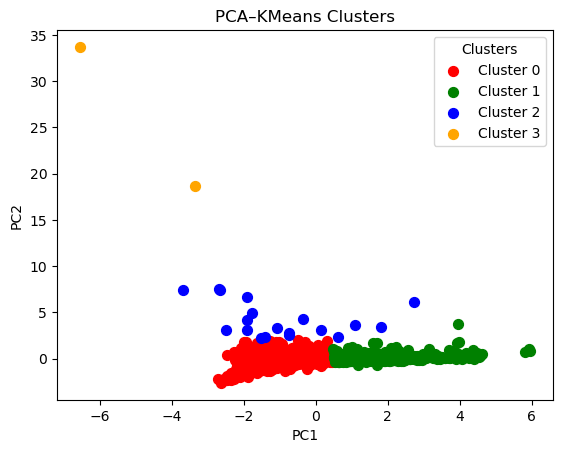

In [21]:

# Define custom colors for each cluster
colors = ['red', 'green', 'blue', 'orange']

# Plot each cluster separately for legend clarity
for i, color in enumerate(colors):
    subset = df_pca_full[df_pca_full['Cluster'] == i]
    plt.scatter(subset.PC1, subset.PC2, c=color, label=f'Cluster {i}', s=50)

# Labels and title
plt.title("PCA–KMeans Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Clusters")
plt.show()




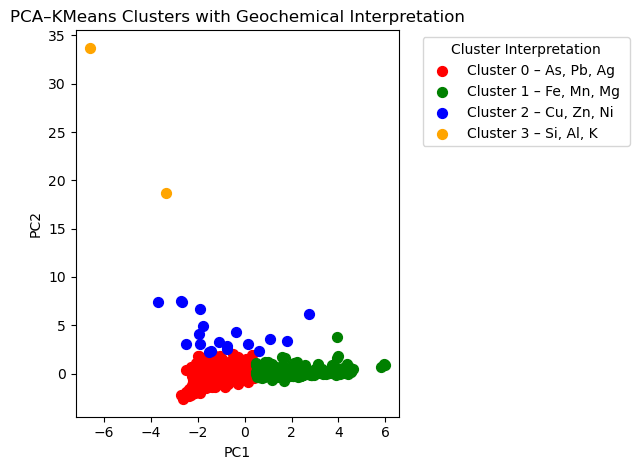

In [22]:
import matplotlib.pyplot as plt

# Define colors and meanings for each cluster
cluster_info = {
    0: ("red",   "Cluster 0 – As, Pb, Ag "),
    1: ("green", "Cluster 1 – Fe, Mn, Mg "),
    2: ("blue",  "Cluster 2 – Cu, Zn, Ni "),
    3: ("orange","Cluster 3 – Si, Al, K ")
}

# Plot each cluster separately for clear legend
for cluster, (color, label) in cluster_info.items():
    subset = df_pca_full[df_pca_full['Cluster'] == cluster]
    plt.scatter(subset.PC1, subset.PC2, c=color, label=label, s=50)

# Labels and title
plt.title("PCA–KMeans Clusters with Geochemical Interpretation")
plt.xlabel("PC1")
plt.ylabel("PC2")

#  legend
plt.legend(title="Cluster Interpretation", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [17]:
df_col['Cluster'] = df_pca_full['Cluster']
cluster_means = df_col.groupby('Cluster')[element_cols].mean()
print(cluster_means)


           Al_pct    Ca_pct    Fe_pct     K_pct    Mg_pct    Mn_pct     P_pct  \
Cluster                                                                         
0.0     -0.213342  0.017867  0.113206 -0.189423 -0.013262  0.028582 -0.002718   
1.0      0.435150 -0.035254 -0.257843  0.397337  0.031368 -0.060916  0.003834   
2.0     -0.008566 -0.014433  0.266515 -0.297271  0.004789  0.159083 -0.045335   
3.0     -0.781173 -0.556483 -0.041587 -0.517042 -0.562615 -0.206356 -0.188961   

           Ti_pct    Ag_ppm    As_ppm    Cu_ppm    Pb_ppm    Zn_ppm    Ni_ppm  \
Cluster                                                                         
0.0     -0.159874  0.036548  0.017789  0.103748  0.042775  0.065305  0.011909   
1.0      0.308308 -0.090359 -0.035256 -0.203865 -0.109811 -0.147137 -0.020763   
2.0      0.429935  0.444739  0.035147 -0.076650  0.549114  0.321751 -0.052958   
3.0     -0.594191 -0.003387 -0.028886  0.651252  0.759553  1.430702 -0.053564   

           Cr_ppm    Co_pp

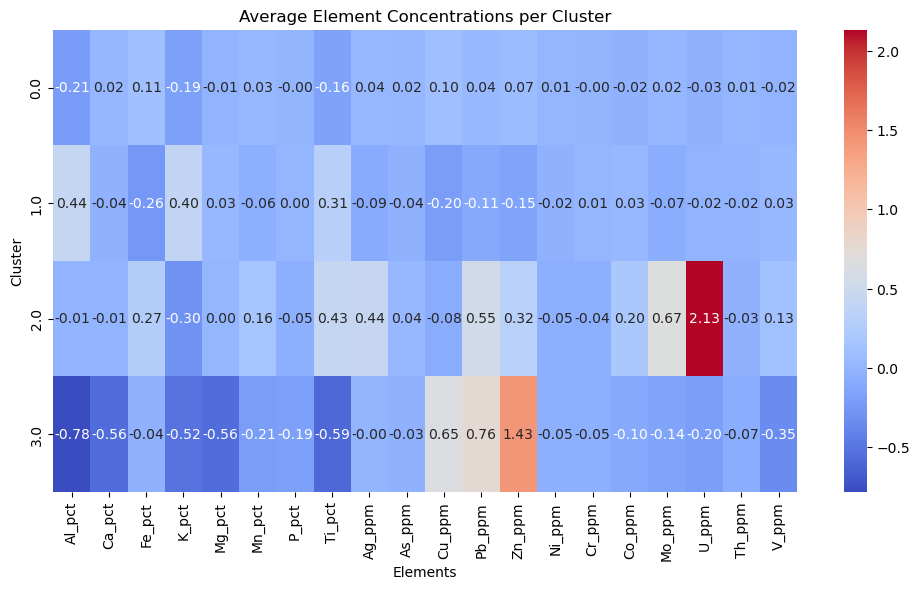

In [18]:
# HEATMAP
# Compute cluster means
cluster_means = df_col.groupby('Cluster')[element_cols].mean()

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Average Element Concentrations per Cluster")
plt.xlabel("Elements")
plt.ylabel("Cluster")
plt.show()

In [19]:
df_col.to_csv("geochem_clusters_with_pca.csv", index=False)


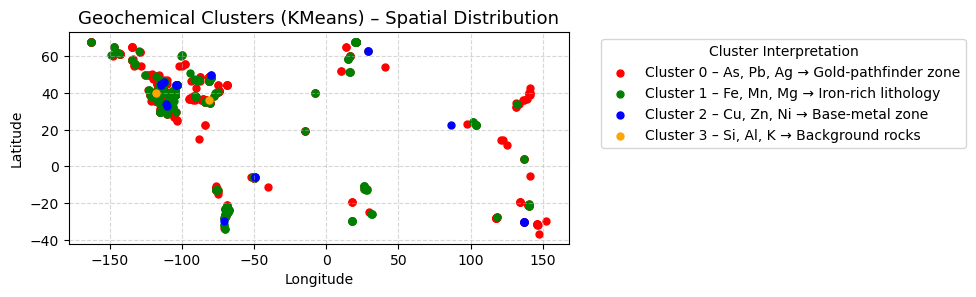

✅ GeoJSON and Shapefile successfully saved — ready for QGIS visualization.


In [23]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -----------------------------
# GeoDataFrame
# -----------------------------
gdf = gpd.GeoDataFrame(
    df_pca_full,
    geometry=[Point(xy) for xy in zip(df_pca_full['Longitude'], df_pca_full['Latitude'])],
    crs="EPSG:4326"  # WGS84 lat/lon
)

# -----------------------------
# clear colors for clusters (same as PCA plot)
# -----------------------------
cluster_colors = {
    0: "red",     # As, Pb, Ag → Gold-pathfinder zone
    1: "green",   # Fe, Mn, Mg → Iron-rich lithology
    2: "blue",    # Cu, Zn, Ni → Base-metal zone
    3: "orange"   # Si, Al, K → Background rocks
}

# colors based on cluster
gdf['Color'] = gdf['Cluster'].map(cluster_colors)

# -----------------------------
# Plotting clusters on geographic map
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 8))

for cluster, color in cluster_colors.items():
    subset = gdf[gdf['Cluster'] == cluster]
    subset.plot(ax=ax, color=color, markersize=25, label=f'Cluster {cluster}')

plt.title("Geochemical Clusters (KMeans) – Spatial Distribution", fontsize=13)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(
    title="Cluster Interpretation",
    labels=[
        "Cluster 0 – As, Pb, Ag → Gold-pathfinder zone",
        "Cluster 1 – Fe, Mn, Mg → Iron-rich lithology",
        "Cluster 2 – Cu, Zn, Ni → Base-metal zone",
        "Cluster 3 – Si, Al, K → Background rocks"
    ],
    bbox_to_anchor=(1.05, 1), loc='upper left'
)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# -----------------------------
# Export Files for QGIS
# -----------------------------
gdf.to_file("geochem_clusters.geojson", driver="GeoJSON")
gdf.to_file("geochem_clusters.shp", driver="ESRI Shapefile")

print("✅ GeoJSON and Shapefile successfully saved — ready for QGIS visualization.")

